# 05 · Validation and Profiling 

## 0. Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.stats import chi2_contingency

RANDOM_STATE = 42
DATA_DIR = "../data"
K = 5
N_RUNS = 50   # number of bootstrap runs

## 1. Load data

In [5]:
X = pd.read_csv(f"{DATA_DIR}/X_pca.csv")
X_scaled = pd.read_csv(f"{DATA_DIR}/X_scaled.csv")
sessions = pd.read_csv(f"{DATA_DIR}/sessions_features.csv")
labels = pd.read_csv(f"{DATA_DIR}/labels_full.csv")
labels_sample = pd.read_csv(f"{DATA_DIR}/labels_sample.csv")

sessions["cluster"] = labels["kmeans"]
revenue = sessions["Revenue"]   # used for validation only, never for clustering
n = len(X)
print("Sessions:", n)

Sessions: 12330


# Part A · Validation

## 2. Stability: K-Means on 50 bootstrap samples

In [8]:
# Each run: draw 12,330 rows WITH replacement, fit K-Means on them,
# then label ALL sessions and compare with the original labels using ARI.
stability_ari = []

for i in range(N_RUNS):
    rng = np.random.RandomState(i)
    boot_rows = rng.choice(n, size=n, replace=True)

    model = KMeans(n_clusters=K, n_init=10, random_state=i)
    model.fit(X.iloc[boot_rows])
    new_labels = model.predict(X)

    stability_ari.append(adjusted_rand_score(labels["kmeans"], new_labels))

print(f"ARI mean:  {np.mean(stability_ari):.3f}")
print(f"ARI range: {min(stability_ari):.3f} – {max(stability_ari):.3f}")

C:\Users\Raina Samanta\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Raina Samanta\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Raina Samanta\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Raina Samanta\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Raina Samanta\anaconda3\Lib\subprocess.py", line 1538, in _execute_child


ARI mean:  0.991
ARI range: 0.979 – 0.997


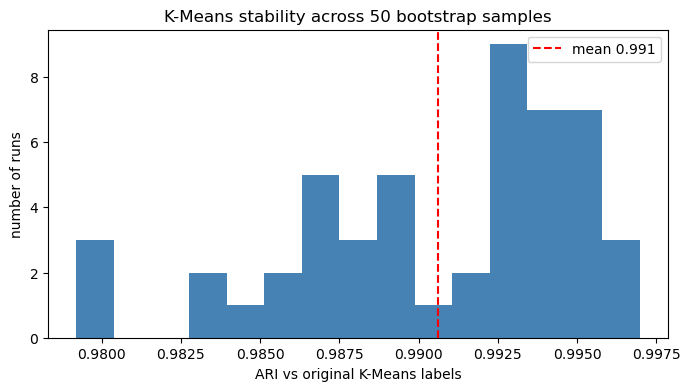

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(stability_ari, bins=15, color="steelblue")
plt.axvline(np.mean(stability_ari), color="red", linestyle="--", label=f"mean {np.mean(stability_ari):.3f}")
plt.xlabel("ARI vs original K-Means labels")
plt.ylabel("number of runs")
plt.title("K-Means stability across 50 bootstrap samples")
plt.legend()
plt.show()

## 3. Size and conversion rate per cluster

In [11]:
overall_rate = revenue.mean()
print(f"Overall conversion rate: {overall_rate:.4f}")

Overall conversion rate: 0.1547


In [12]:
conversion = sessions.groupby("cluster")["Revenue"].agg(sessions="count", purchases="sum", conversion_rate="mean")
conversion["share_of_sessions"] = conversion["sessions"] / n
conversion.round(3)

,sessions,purchases,conversion_rate,share_of_sessions
cluster,,,,
0,3534,771,0.218,0.287
1,797,3,0.004,0.065
2,5029,522,0.104,0.408
3,918,104,0.113,0.074
4,2052,508,0.248,0.166


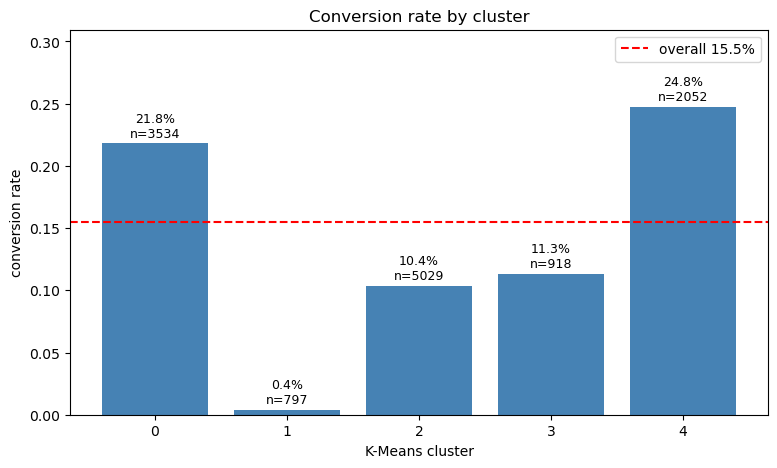

In [13]:
plt.figure(figsize=(9, 5))
plt.bar(conversion.index.astype(str), conversion["conversion_rate"], color="steelblue")
plt.axhline(overall_rate, color="red", linestyle="--", label=f"overall {overall_rate:.1%}")

# Write the rate and size above each bar
for x, (rate, size) in enumerate(zip(conversion["conversion_rate"], conversion["sessions"])):
    plt.text(x, rate + 0.005, f"{rate:.1%}\nn={size}", ha="center", fontsize=9)

plt.ylim(0, conversion["conversion_rate"].max() * 1.25)
plt.xlabel("K-Means cluster")
plt.ylabel("conversion rate")
plt.title("Conversion rate by cluster")
plt.legend()
plt.show()

In [14]:
# Self-check: sizes add up and every rate lies between 0 and 1
print("Sessions add up to:", conversion["sessions"].sum())
print("All rates between 0 and 1:", conversion["conversion_rate"].between(0, 1).all())

Sessions add up to: 12330
All rates between 0 and 1: True


## 4. Chi-square test: is cluster related to Revenue?

In [16]:
table = pd.crosstab(sessions["cluster"], revenue)
chi2, p_value, dof, expected = chi2_contingency(table)

# Cramér's V: strength of the relationship, from 0 (none) to 1 (perfect)
cramers_v = np.sqrt(chi2 / table.values.sum())

print("Chi-square:", round(chi2, 1))
print("Degrees of freedom:", dof)
print(f"p-value: {p_value:.1e}")
print("Cramér's V:", round(cramers_v, 3))
print("Smallest expected count:", round(expected.min(), 1), "(should be at least 5)")

Chi-square: 494.6
Degrees of freedom: 4
p-value: 9.9e-106
Cramér's V: 0.2
Smallest expected count: 123.3 (should be at least 5)


# Part B · Profiling

## 5. Profile in real units (median per cluster)

In [19]:
# Medians, because the raw columns are very skewed and means would be pulled by a few extreme sessions
PROFILE_COLS = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "total_pages", "total_duration", "avg_seconds_per_page",
    "BounceRates", "ExitRates", "product_page_share", "product_time_share",
]

median_profile = sessions.groupby("cluster")[PROFILE_COLS].median().T
median_profile.round(2)

cluster,0,1,2,3,4
Administrative,3.00,0.0,0.00,4.00,4.00
Administrative_Duration,74.88,0.0,0.00,106.25,109.82
Informational,0.00,0.0,0.00,0.00,2.00
Informational_Duration,0.00,0.0,0.00,0.00,92.00
ProductRelated,29.00,1.0,12.00,6.00,46.00
ProductRelated_Duration,994.71,0.0,377.00,115.75,1785.75
total_pages,32.00,1.0,12.00,10.00,55.00
total_duration,1127.54,0.0,377.50,252.83,2173.16
avg_seconds_per_page,32.38,0.0,28.08,22.97,37.70
BounceRates,0.00,0.2,0.00,0.00,0.00


In [20]:
# Share of sessions in each cluster with zero pages of each type, and with zero duration
extra = pd.DataFrame({
    "no_admin_pages": sessions.groupby("cluster")["Administrative"].apply(lambda s: (s == 0).mean()),
    "no_info_pages": sessions.groupby("cluster")["Informational"].apply(lambda s: (s == 0).mean()),
    "zero_duration": sessions.groupby("cluster")["total_duration"].apply(lambda s: (s == 0).mean()),
})
extra.round(2)

,no_admin_pages,no_info_pages,zero_duration
cluster,,,
0,0.00,0.95,0.00
1,0.99,1.00,0.88
2,0.94,0.96,0.00
3,0.03,0.79,0.02
4,0.12,0.00,0.00


## 6. Standardized profile heatmap

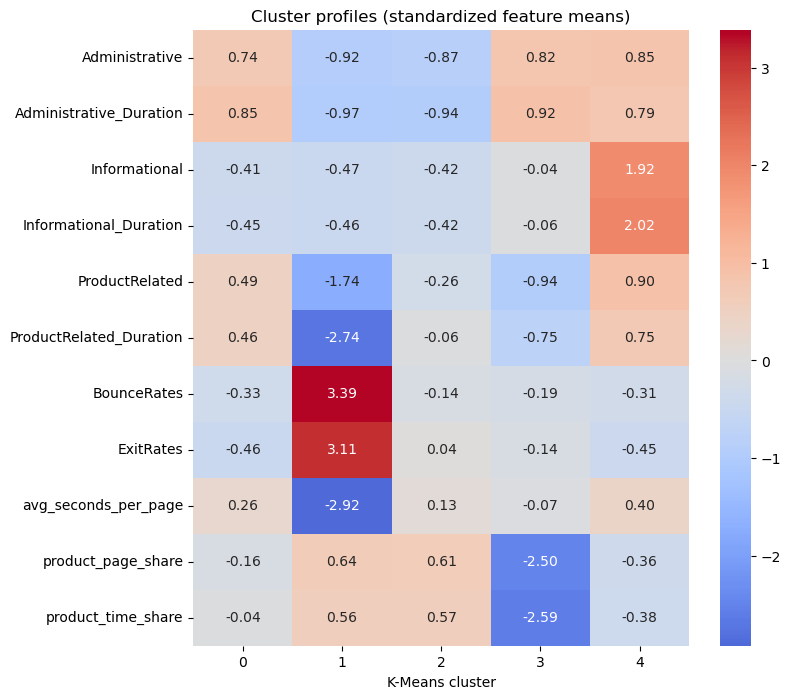

In [22]:
# Mean of each scaled clustering feature per cluster.
# 0 = average session; +1 = one standard deviation above average; -1 = one below.
scaled_profile = X_scaled.groupby(labels["kmeans"]).mean().T

plt.figure(figsize=(8, 8))
sns.heatmap(scaled_profile, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.xlabel("K-Means cluster")
plt.title("Cluster profiles (standardized feature means)")
plt.show()

## 7. Context: who, when and from where (profile-only columns)

In [24]:
# Visitor type mix per cluster (each row adds up to 1)
print("Overall:", sessions["VisitorType"].value_counts(normalize=True).round(3).to_dict())
pd.crosstab(sessions["cluster"], sessions["VisitorType"], normalize="index").round(3)

Overall: {'Returning_Visitor': 0.856, 'New_Visitor': 0.137, 'Other': 0.007}


VisitorType,New_Visitor,Other,Returning_Visitor
cluster,,,
0,0.179,0.004,0.817
1,0.036,0.021,0.942
2,0.098,0.007,0.895
3,0.394,0.015,0.590
4,0.088,0.001,0.910


In [25]:
# Weekend share per cluster
print("Overall weekend share:", round(sessions["Weekend"].mean(), 3))
sessions.groupby("cluster")["Weekend"].mean().round(3)

Overall weekend share: 0.233


cluster
0    0.241
1    0.164
2    0.220
3    0.235
4    0.276
Name: Weekend, dtype: float64

In [26]:
# Average closeness to a special day (0 to 1) per cluster
print("Overall:", round(sessions["SpecialDay"].mean(), 3))
sessions.groupby("cluster")["SpecialDay"].mean().round(3)

Overall: 0.061


cluster
0    0.040
1    0.085
2    0.088
3    0.036
4    0.035
Name: SpecialDay, dtype: float64

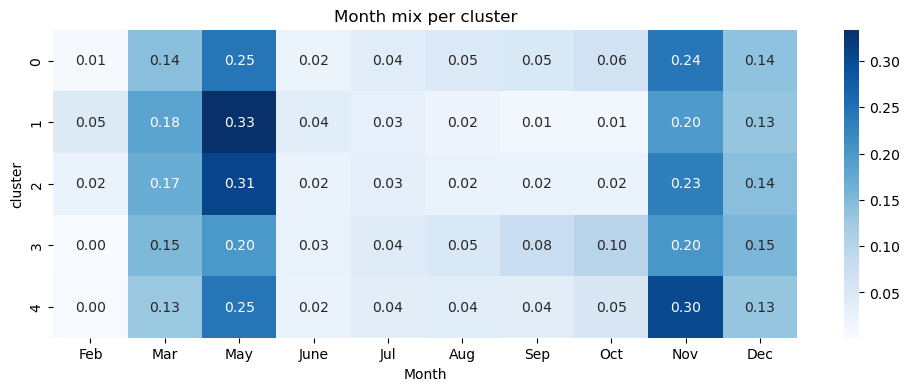

In [27]:
# Month mix per cluster (each row adds up to 1)
MONTH_ORDER = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_mix = pd.crosstab(sessions["cluster"], sessions["Month"], normalize="index")[MONTH_ORDER]

plt.figure(figsize=(12, 4))
sns.heatmap(month_mix, annot=True, fmt=".2f", cmap="Blues")
plt.title("Month mix per cluster")
plt.show()

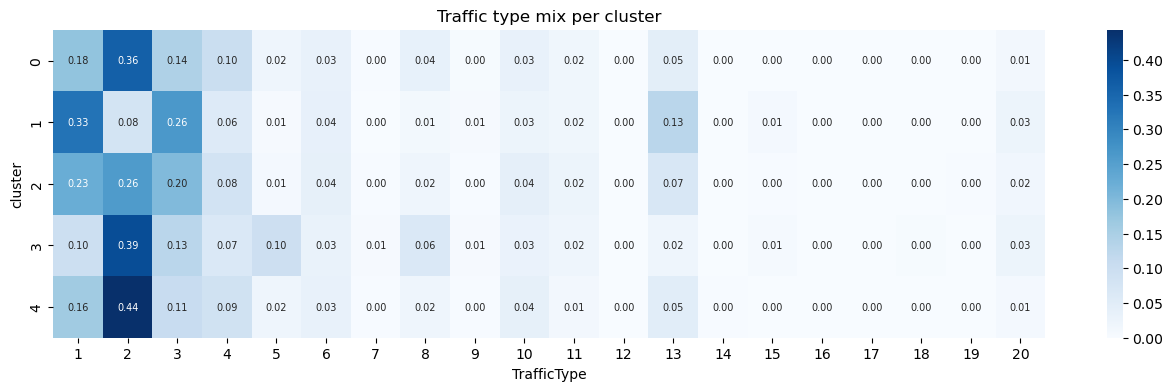

In [28]:
# Traffic type mix per cluster (codes are categories, not quantities)
traffic_mix = pd.crosstab(sessions["cluster"], sessions["TrafficType"], normalize="index")

plt.figure(figsize=(16, 4))
sns.heatmap(traffic_mix, annot=True, fmt=".2f", cmap="Blues", annot_kws={"size": 7})
plt.title("Traffic type mix per cluster")
plt.show()

## 8. Do the other methods find the same groups?

In [30]:
# Row shares: for each K-Means cluster, where do its sessions go in the other method?
print("K-Means vs GMM")
pd.crosstab(labels["kmeans"], labels["gmm"], normalize="index").round(2)

K-Means vs GMM


gmm,0,1,2,3,4
kmeans,,,,,
0,0.05,0.95,0.00,0.00,0.00
1,0.00,0.00,0.85,0.01,0.14
2,0.04,0.06,0.00,0.01,0.90
3,0.04,0.69,0.00,0.27,0.00
4,0.98,0.00,0.00,0.02,0.00


In [31]:
print("K-Means vs DBSCAN (-1 = noise)")
pd.crosstab(labels["kmeans"], labels["dbscan"], normalize="index").round(2)

K-Means vs DBSCAN (-1 = noise)


dbscan,-1,0,1,2,3,4
kmeans,,,,,,
0,0.01,0.00,0.95,0.00,0.04,0.00
1,0.02,0.85,0.14,0.00,0.00,0.00
2,0.01,0.00,0.96,0.00,0.04,0.00
3,0.25,0.00,0.69,0.01,0.03,0.01
4,0.09,0.00,0.00,0.00,0.91,0.00


In [32]:
print("K-Means vs Agglomerative (3,000 sample)")
pd.crosstab(labels_sample["kmeans"], labels_sample["agglo"], normalize="index").round(2)

K-Means vs Agglomerative (3,000 sample)


agglo,0,1,2,3,4
kmeans,,,,,
0,0.16,0.01,0.02,0.00,0.81
1,0.12,0.00,0.01,0.87,0.00
2,0.96,0.03,0.00,0.00,0.01
3,0.00,0.04,0.94,0.00,0.02
4,0.00,0.96,0.04,0.00,0.00
